In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages : Annotated[list,add_messages] # appends msg to list instead of overwriting them


In [3]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    google_api_key = os.getenv("GOOGLE_API_KEY")
)

In [ ]:
# Node functionality
def chatbot(state : State):
    return {"messages" : [llm.invoke(state["messages"])]}

In [ ]:
graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph = graph_builder.compile()

In [ ]:
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass        

In [ ]:
response = graph.invoke({"messages" : "Hi"})

In [ ]:
response["messages"][-1].text

In [ ]:
for event in graph.stream({"messages" : "Hi How are you?"}):
    for value in event.values():
        print(value)

## Chatbot with tool

In [4]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

In [5]:
## Custom function
def multiply(a:int, b:int)->int:
    """Multiply a and b
    
    Args : 
        a(int) : first int
        b(int) : second int

    Returns :    
        int : output int
    """

    return a * b

In [6]:
tools = [tool,multiply]

In [7]:
llm_with_tool = llm.bind_tools(tools)

In [8]:
llm_with_tool

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.2'}}, output_version=None, profile={'name': 'Gemini 3.1 Flash Lite', 'release_date': '2026-05-07', 'last_updated': '2026-05-07', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.1-flash-lite', temperature=None, client=<google.genai.client.Client o

In [9]:
# Stategraph
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state : State):
    return {"messages" : [llm_with_tool.invoke(state["messages"])]}

 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If latest msg from assistant is tool call -> tools_condition routes to tools else to END
    tools_condition
)
builder.add_edge("tools",END)


graph = builder.compile()

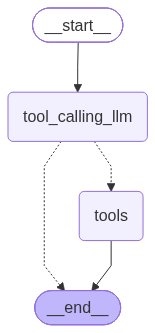

In [10]:
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass        

In [12]:
response = graph.invoke({"messages" : "What is the latest ai news?"})

In [15]:
response["messages"][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.computerworld.com/article/4015023/openai-latest-news-and-insights.html", "title": "OpenAI: Latest news and insights", "content": "April 1, 2025: A wave of new AI products is hitting the market, signaling a shift toward more autonomous, task-completing systems that could reshape how businesses and consumers interact with digital services: Amazon has unveiled Nova Act, an AI agent designed to operate a web browser much like a human user; OpenAI said it will release an open-weight language model; and China’s Zhipu AI introduced a free AI assistant aimed at strengthening its position in the domestic market and competing with Western tech giants.\\n\\n### OpenAI, Google AI data centers are under stress after new genAI model launches [...] May 30, 2025: OpenAI’s most advanced AI models are showing a disturbing new behavior: they are refusing to obey direct human commands t

In [16]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the latest ai news?
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (call_3105095)
 Call ID: call_3105095
  Args:
    time_range: week
    query: latest AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.computerworld.com/article/4015023/openai-latest-news-and-insights.html", "title": "OpenAI: Latest news and insights", "content": "April 1, 2025: A wave of new AI products is hitting the market, signaling a shift toward more autonomous, task-completing systems that could reshape how businesses and consumers interact with digital services: Amazon has unveiled Nova Act, an AI agent designed to operate a web browser muc

In [17]:
response2 = graph.invoke({"messages" : "what is 3984 * 3994"})
for m in response2['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 3984 * 3994
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (call_2479275)
 Call ID: call_2479275
  Args:
    a: 3984
    b: 3994
================================= Tool Message =================================
Name: multiply

15912096


## ReAct Agent

In [18]:
# Stategraph
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state : State):
    return {"messages" : [llm_with_tool.invoke(state["messages"])]}

 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If latest msg from assistant is tool call -> tools_condition routes to tools else to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

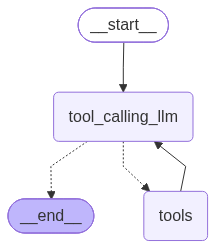

In [19]:
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass        

In [20]:
response3 = graph.invoke({"messages" : "Give me the latest box office earning of Odyssey 2026 and them what is 3984 * 3994"})
for m in response3['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the latest box office earning of Odyssey 2026 and them what is 3984 * 3994
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (call_2691911)
 Call ID: call_2691911
  Args:
    query: Odyssey 2026 movie box office earnings
  multiply (call_2691912)
 Call ID: call_2691912
  Args:
    a: 3984
    b: 3994
================================= Tool Message =================================
Name: tavily_search

{"query": "Odyssey 2026 movie box office earnings", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.the-numbers.com/movie/Odyssey-The-(2026)", "title": "The Odyssey (2026) - Box Office and Financial Information", "content": "| Territory | Release Date | Opening Weekend | Opening Weekend Screens/Theaters | Maximum Screens/Theaters | Theatrical Engagements | Total Box Office | Report Date |\n ---  

In [21]:
response3["messages"][-1].text

'As of the latest reports, *The Odyssey* (2026) has reached a **worldwide total box office of $1.14 billion**.\n\nRegarding your math question, **3984 * 3994 = 15,912,096**.'

## Adding memory in agentic graph

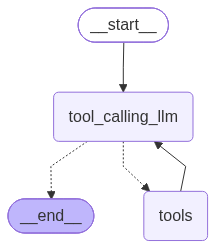

In [22]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Stategraph
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state : State):
    return {"messages" : [llm_with_tool.invoke(state["messages"])]}

 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If latest msg from assistant is tool call -> tools_condition routes to tools else to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile(checkpointer=memory)


from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass        


In [24]:
config = {"configurable" : {"thread_id" : "1"}}

response4 = graph.invoke({"messages" : "Hi my name is Saumya"} , config = config)

In [25]:
for m in response4['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Saumya
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Saumya! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EnEKbwERTTIPq+fFVv7LSJRjhGlGRwEYTbF8SNUcbIOSvSLo7LwySIWgdwmkh29DSj+eTKuTr93uRx4W/5uzqmK8+BeOma8VEviU8OWlOAF6WwICpop7IbvrSENNI8mWCweH9VzCIoHkukkWteACftJR1w=='}}]


In [26]:
response5 = graph.invoke({"messages" : "What is my name?"} , config = config)

for m in response5['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Saumya
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Saumya! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EnEKbwERTTIPq+fFVv7LSJRjhGlGRwEYTbF8SNUcbIOSvSLo7LwySIWgdwmkh29DSj+eTKuTr93uRx4W/5uzqmK8+BeOma8VEviU8OWlOAF6WwICpop7IbvrSENNI8mWCweH9VzCIoHkukkWteACftJR1w=='}}]
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Your name is Saumya.', 'extras': {'signature': 'EnEKbwERTTIPhB8LWk5sZdjDcwVSTweGK+AyqtGGjSYl0CUq2hiTkl9GLJsjvPB1rDxqR1F7nCokYIVHIpFye/FNWPSCBEGD7tTeTI2UNlpHOSQ+N+XY7dCZ42Q7D/geOFhGLgMrY60h3Ozv0Qe9WmC85A=='}}]


In [27]:
response5['messages'][-1].text

'Your name is Saumya.'

## Streaming

In [28]:
def superbot(state : State):
    return {"messages" : [llm.invoke(state["messages"])]}

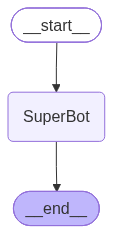

In [29]:
memory = MemorySaver()

graph = StateGraph(State)

graph.add_node("SuperBot",superbot)

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder = graph.compile(checkpointer=memory)

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [31]:
config = {"configurable" : {"thread_id" : "2"}}

graph_builder.invoke({"messages" : "Hi i am saumya and i love spiderman"},config = config)

{'messages': [HumanMessage(content='Hi i am saumya and i love spiderman', additional_kwargs={}, response_metadata={}, id='3cc46024-be89-41af-a20f-ea1245d42fc5'),
  AIMessage(content=[{'type': 'text', 'text': 'Hi Saumya! It’s nice to meet you.\n\nSpider-Man is an awesome choice! There’s so much to love about him—whether it’s his quick wit, the way he swings through New York City, or the fact that he’s just a regular person trying to do the right thing while balancing his everyday life.\n\nDo you have a favorite version of Spider-Man? Are you a fan of Peter Parker (like in the Tobey Maguire, Andrew Garfield, or Tom Holland movies), or do you prefer Miles Morales from the *Spider-Verse* films?', 'extras': {'signature': 'EnEKbwERTTIPDQ1NSALIz5AYi6DNb9uSjDe5rFodiwh5y6qhQ6mM+4UgEnvyF5E7d9/YfbimUmayWCLNXuP3aAsaWShcyOU4oL32lTjCDc5yCLAeHD3q+7Nwayg1666sRFUFI8ukelhsCRJu263L4QSzyg=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safet

## Streaming : 

Methods : .stream() and astream()
- These methods are sync and async methods for streaming back results.

Additional Params : 
- values : Streams the full state of graph after each node is called.
- updates : Stream updates to the state of graph after each node is called.

In [39]:
config = {"configurable" : {"thread_id" : "5"}}

for chunk in graph_builder.stream({"messages" : "Hi I am SSS and i love Pokemon"},config = config, stream_mode = "updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content=[{'type': 'text', 'text': "Hi SSS! It’s great to meet a fellow Pokémon fan. There’s always something new to love about that world, whether it's the classic games, the competitive scene, the trading cards, or the anime.\n\nTo get to know your Pokémon taste a little better:\n\n*   **Who is your all-time favorite Pokémon?**\n*   **Do you have a favorite generation or region?**\n*   **Are you playing any of the current games (like Scarlet/Violet), or are you more into the classics?**\n\nLet me know—I’m always down to talk about team building, lore, or just general Pokémon excitement!", 'extras': {'signature': 'EnEKbwERTTIP1fbLeTQclLwYH/r/zs+xmSPuLEOO3wJC6jcpEKPxIDi9qO9CLFJZNYvojmXSptnpqF/EU6fgP9puAk65ZXtEC+e61ktDI5tiB5K5O+jJTakYOjyFnQZ3kSkYNDjaJxJftPl5Kgqxf7Sbaw=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00

In [42]:
config = {"configurable" : {"thread_id" : "7"}}

for chunk in graph_builder.stream({"messages" : "Hi I am SSS and i love Pokemon"},config = config, stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi I am SSS and i love Pokemon', additional_kwargs={}, response_metadata={}, id='9b74c88b-74a2-4c8c-80f0-03ab2feb31a2')]}
{'messages': [HumanMessage(content='Hi I am SSS and i love Pokemon', additional_kwargs={}, response_metadata={}, id='9b74c88b-74a2-4c8c-80f0-03ab2feb31a2'), AIMessage(content=[{'type': 'text', 'text': "Hi SSS! It’s great to meet you! As a fellow fan of the Pokémon world, I’d love to chat about it.\n\nTo get things started, I have to ask:\n\n1.  **Who is your favorite Pokémon of all time?** (Is it a classic like Pikachu, a legendary, or something more obscure?)\n2.  **Which region is your favorite to explore?** (Kanto, Johto, Hoenn, Sinnoh, etc.?)\n3.  **Do you play the games, watch the anime, or collect the cards?**\n\nI'm ready to talk stats, lore, or just geek out over team building whenever you are!", 'extras': {'signature': 'EnEKbwERTTIP+8KMuWmxBtNC1bip6jy2Ub6+c5JXx3pwD01UrXqJnCIvNnAcYjS1n4EqWFEnLuFawUBxugwR1bvWc3l56ZiV/Dy9gS5